<h1>Application of Closed-loop learning to k-means clustering of Iris dataset</h1>

<h2>Gabriele Cerioli, Bsc Physics, University of Trieste</h2>

<h3>Defining Euclidean distance and the main function kmeans</h3>

In [39]:
import numpy as np

def euclidean_distance(a, b):
    # Euclidean distance between two vectors
    return np.linalg.norm(a - b)
from sklearn.cluster import KMeans

In [40]:
def mean_clusters(data_matrix, cluster_assignments, n_clusters):
    import numpy as np
    cluster_assignments = cluster_assignments.astype(int)  # ensure integer indices
    
    # Sum of points per cluster
    sums = np.zeros((n_clusters, data_matrix.shape[1]))
    np.add.at(sums, cluster_assignments, data_matrix)
    
    # Count of points per cluster
    counts = np.bincount(cluster_assignments, minlength=n_clusters).reshape(-1, 1)
    
    # Mean = sums / counts (safe division)
    mean_cluster = np.divide(sums, counts, where=counts > 0)
    return mean_cluster


def variance_clusters(data_matrix, cluster_assignments, n_clusters):
    import numpy as np
    # Compute cluster means first
    mean_cluster = mean_clusters(data_matrix, cluster_assignments, n_clusters)
    
    # Sum of squared deviations per cluster
    sq_dev = np.zeros((n_clusters, data_matrix.shape[1]))
    np.add.at(sq_dev, cluster_assignments, (data_matrix - mean_cluster[cluster_assignments])**2)
    
    # Count of points per cluster
    counts = np.bincount(cluster_assignments, minlength=n_clusters).reshape(-1, 1)
    
    # Variance = sum of squared deviations / count
    variance_cluster = np.divide(sq_dev, counts, where=counts>0)
    return variance_cluster

In [41]:


def plot_clusters(data_matrix, cluster_assignments, centroids):
    import matplotlib.pyplot as plt
    
    # Define feature pairs to plot (x_index, y_index, x_label, y_label)
    feature_pairs = [
        (0, 1, "Sepal Length (cm)", "Sepal Width (cm)"),
        (0, 2, "Sepal Length (cm)", "Petal Length (cm)"),
        (0, 3, "Sepal Length (cm)", "Petal Width (cm)"),
        (1, 2, "Sepal Width (cm)", "Petal Length (cm)"),
        (1, 3, "Sepal Width (cm)", "Petal Width (cm)"),
        (2, 3, "Petal Length (cm)", "Petal Width (cm)")
    ]
    
    fig, axes = plt.subplots(2, 3, figsize=(10, 8))  # 2 rows, 3 columns
    axes = axes.ravel()  # flatten 2D array of axes
    
    for ax, (x_idx, y_idx, x_label, y_label) in zip(axes, feature_pairs):
        # Scatter plot of points colored by cluster
        ax.scatter(data_matrix[:, x_idx], data_matrix[:, y_idx],
                   c=cluster_assignments, cmap='winter', alpha=0.6)
        # Scatter plot of centroids
        ax.scatter(centroids[:, x_idx], centroids[:, y_idx],
                   c='red', marker='X', s=100, label='Centroids')
        ax.set_xlabel(x_label)
        ax.set_ylabel(y_label)
    
    # Add legend only to the first subplot
    axes[0].legend()
    
    fig.suptitle("Visualisation of Clusters and their Centroids", fontsize=16, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()
    return



In [42]:
def update_dataset(data_matrix, cluster_assignments, M, n_clusters, random_state=None):
    import numpy as np
    means=mean_clusters(data_matrix,cluster_assignments,n_clusters)
    variances=variance_clusters(data_matrix,cluster_assignments,n_clusters)

    rng = np.random.default_rng(random_state)

    cluster_assignments = cluster_assignments.astype(int)
    
    # Calcola la distribuzione dei cluster (peso proporzionale alla dimensione del cluster)
    weights = np.bincount(cluster_assignments, minlength=means.shape[0]).astype(float)
    weights /= weights.sum()
    
    # Se variances ha zeri, aggiungo un rumore minimo per evitare errori
    safe_variances = np.where(variances == 0, 1e-6, variances)

    # Scelta dei cluster per generare punti sintetici
    cluster_indices = rng.choice(len(means), size=M, p=weights)
    
    # Generazione dei punti sintetici dalla distribuzione dei cluster
    synthetic_points = rng.normal(loc=means[cluster_indices], scale=np.sqrt(safe_variances[cluster_indices]))

    # 🔥 Aggiungo i nuovi punti al dataset originale
    new_data = np.vstack((data_matrix, synthetic_points))

    return new_data



<h3>Main Algorithm</h3>

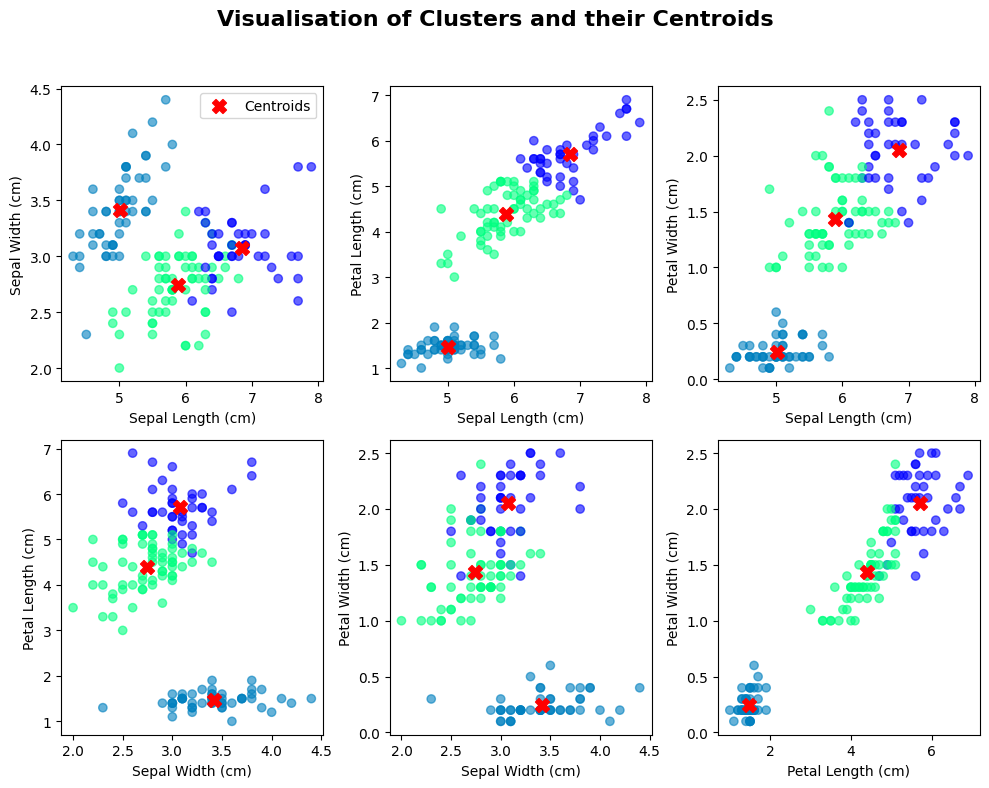

39 50 61
Original Means: [[6.85384615 3.07692308 5.71538462 2.05384615]
 [5.006      3.418      1.464      0.244     ]
 [5.88360656 2.74098361 4.38852459 1.43442623]]
Original variances: [[0.2322288  0.08023669 0.25360947 0.08556213]
 [0.121764   0.142276   0.029504   0.011264  ]
 [0.19743617 0.08438592 0.2574093  0.08848697]]
Means: [[6.8502446  3.00766936 5.7395184  2.01437321]
 [5.04254308 3.38334768 1.47994136 0.26425437]
 [5.8565215  2.74910187 4.37918808 1.434896  ]]
Variances: [[0.23440843 0.07398342 0.21013041 0.08849606]
 [0.13805561 0.13278308 0.02520443 0.00714987]
 [0.18666392 0.07214274 0.19804074 0.07495838]]


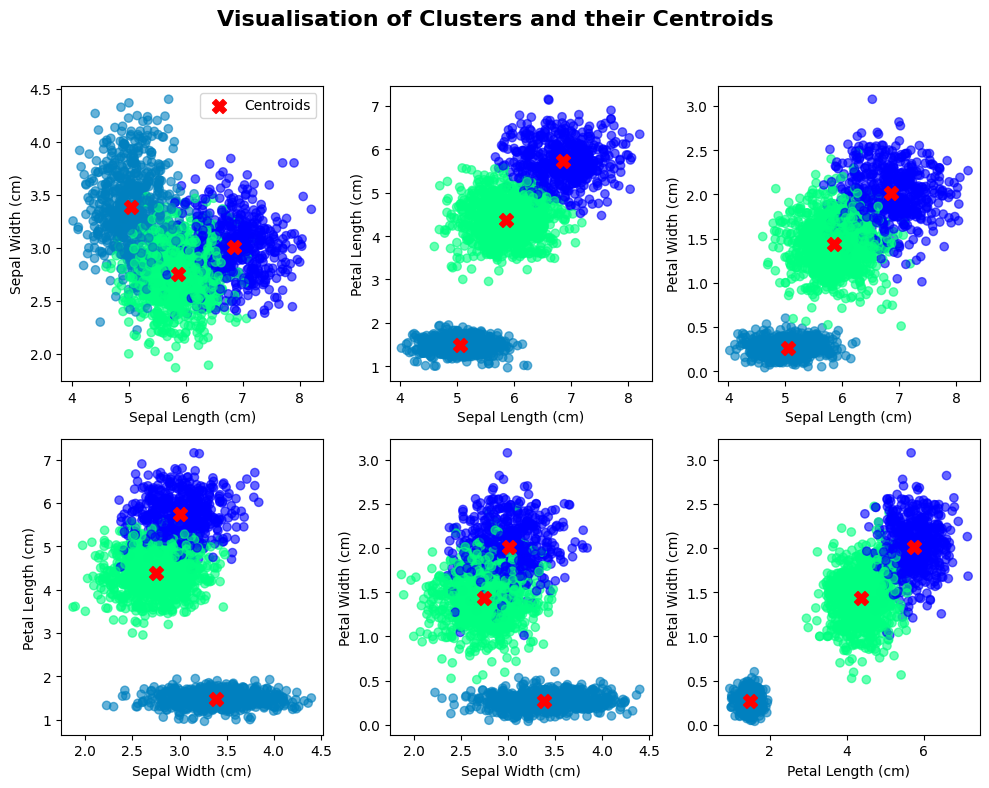

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

M = 20  # points to be added as synthetic data
df = pd.read_csv('Iris.csv')

selected_columns = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
data_matrix = df[selected_columns].to_numpy()

# Initial fit of KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(data_matrix)
cluster_assignments = kmeans.labels_
orig_assignments=cluster_assignments.copy()
# Compute cluster means using the existing helper
centers = mean_clusters(data_matrix, cluster_assignments, 3)
mean_first_ex=centers.copy()
plot_clusters(data_matrix, cluster_assignments, centers)

print(np.sum(cluster_assignments == 0),
      np.sum(cluster_assignments == 1),
      np.sum(cluster_assignments == 2))

new_data = data_matrix.copy()
steps = 100  # Number of iterations
means = mean_clusters(data_matrix, cluster_assignments, 3)
variances = variance_clusters(data_matrix, cluster_assignments, 3)

print("Original Means:", means)
print("Original variances:", variances)

# Iteratively augment the dataset and re-cluster.
for i in range(steps):
    # Re-fit KMeans on the current dataset and obtain assignments
    kmeans = KMeans(n_clusters=3, random_state=42)
    cluster_assignments = kmeans.fit_predict(new_data)
    
    # Recompute cluster statistics on the updated dataset
    means = mean_clusters(new_data, cluster_assignments, 3)
    variances = variance_clusters(new_data, cluster_assignments, 3)
    
    # Update dataset by adding synthetic points sampled from cluster distributions
    # Pass n_clusters as integer (3) to match update_dataset signature.
    new_data = update_dataset(new_data, cluster_assignments, M, 3, random_state=42 + i)

# Final recomputation on the resulting dataset
kmeans = KMeans(n_clusters=3, random_state=42)
cluster_assignments = kmeans.fit_predict(new_data)
means_final = mean_clusters(new_data, cluster_assignments, 3)
variances = variance_clusters(new_data, cluster_assignments, 3)
mean_final_ex=means_final.copy()
print("Means:", means_final)
print("Variances:", variances)
plot_clusters(new_data, cluster_assignments, means_final)
cluster_assignments_original=cluster_assignments.copy()

In [44]:
from scipy.stats import multivariate_normal
def assign_clusters_gaussian(X, means, variances):
    
    K = means.shape[0]
    N = data_matrix.shape[0]

    # Se variances è diagonale → costruiamo matrici di covarianza
    covs = np.array([np.diag(var) for var in variances])

    # Calcolo delle probabilità gaussiane
    log_probs = np.zeros((N, K))
    for k in range(K):
        rv = multivariate_normal(mean=means[k], cov=covs[k], allow_singular=True)
        log_probs[:, k] = rv.logpdf(X)

    # Assegnazione al cluster con max log-probability
    cluster_assignments = np.argmax(log_probs, axis=1)
    return cluster_assignments
cluster_assignments=assign_clusters_gaussian(data_matrix,means,variances)
print(cluster_assignments)

[2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 0 1 1 1 0
 1 1 0 0 1 1 1 0 0 1 0 1 0 1 1 0 0 1 0 1 1 1 0 0 1 1 1 0 1 1 0 0 1 0 0 0 1
 1 0]


In [45]:
from sklearn.metrics import confusion_matrix, davies_bouldin_score

def purity_score(y_true, y_pred):
    """
    Compute purity between true labels and clustering assignments.
    """
    contingency_matrix = confusion_matrix(y_true, y_pred)
    max_per_cluster = contingency_matrix.max(axis=0)
    purity = max_per_cluster.sum() / contingency_matrix.sum()
    return purity

# ground truth for the original 150 Iris samples
ground_truth = np.array([0]*50 + [1]*50 + [2]*50)

print("Purity score before CLL: ", purity_score(ground_truth, orig_assignments))
print("Purity after CLL:", purity_score(ground_truth, cluster_assignments))

Purity score before CLL:  0.8866666666666667
Purity after CLL: 0.8533333333333334


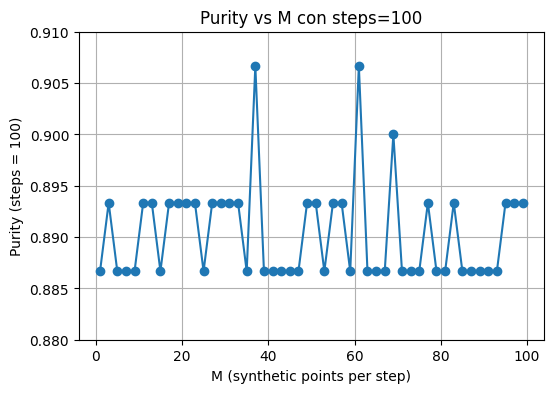

M values: [ 1  3  5  7  9 11 13 15 17 19 21 23 25 27 29 31 33 35 37 39 41 43 45 47
 49 51 53 55 57 59 61 63 65 67 69 71 73 75 77 79 81 83 85 87 89 91 93 95
 97 99]
Purity results: [np.float64(0.8866666666666667), np.float64(0.8933333333333333), np.float64(0.8866666666666667), np.float64(0.8866666666666667), np.float64(0.8866666666666667), np.float64(0.8933333333333333), np.float64(0.8933333333333333), np.float64(0.8866666666666667), np.float64(0.8933333333333333), np.float64(0.8933333333333333), np.float64(0.8933333333333333), np.float64(0.8933333333333333), np.float64(0.8866666666666667), np.float64(0.8933333333333333), np.float64(0.8933333333333333), np.float64(0.8933333333333333), np.float64(0.8933333333333333), np.float64(0.8866666666666667), np.float64(0.9066666666666666), np.float64(0.8866666666666667), np.float64(0.8866666666666667), np.float64(0.8866666666666667), np.float64(0.8866666666666667), np.float64(0.8866666666666667), np.float64(0.8933333333333333), np.float64(0.893333

In [46]:
# Fisso il numero di steps a 100, scorro i diversi M in M_values e calcolo la purity
steps = 100
M_values=np.arange(1,100,2)
purity_results = []
for M_try in M_values:
    new_data = data_matrix.copy()
    # iterazioni CLL
    for t in range(steps):
        kmeans = KMeans(n_clusters=3,init='k-means++', random_state=42)
        cluster_assigns = kmeans.fit_predict(new_data)
        new_data = update_dataset(new_data, cluster_assigns, M_try, 3, random_state=42+t)
    # cluster finale e purity sui primi 150 campioni (dataset originale)
    kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42)
    final_assigns = kmeans.fit_predict(new_data)
    purity_val = purity_score(ground_truth, final_assigns[:len(ground_truth)])
    purity_results.append(purity_val)

# Plot
plt.figure(figsize=(6,4))
plt.plot(M_values, purity_results, marker='o')
plt.xlabel('M (synthetic points per step)')
plt.ylabel('Purity (steps = 100)')
plt.title('Purity vs M con steps=100')
plt.ylim(0.88,0.91)
plt.grid(True)
plt.show()

print("M values:", M_values)
print("Purity results:", purity_results)

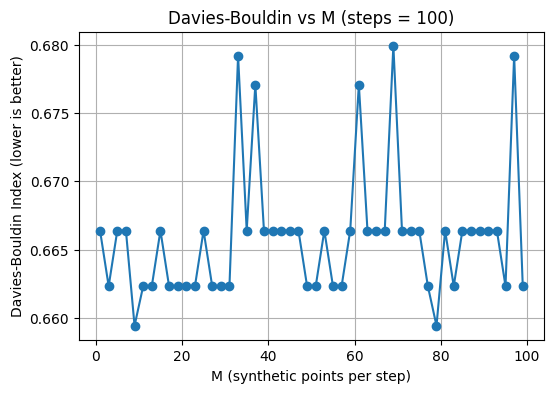

M values: [ 1  3  5  7  9 11 13 15 17 19 21 23 25 27 29 31 33 35 37 39 41 43 45 47
 49 51 53 55 57 59 61 63 65 67 69 71 73 75 77 79 81 83 85 87 89 91 93 95
 97 99]
DB results: [0.6663912107101494, 0.662322864989869, 0.6663912107101494, 0.6663912107101494, 0.6594268353117189, 0.662322864989869, 0.662322864989869, 0.6663912107101494, 0.662322864989869, 0.662322864989869, 0.662322864989869, 0.662322864989869, 0.6663912107101494, 0.662322864989869, 0.662322864989869, 0.662322864989869, 0.679192706381635, 0.6663912107101494, 0.6770794419654039, 0.6663912107101494, 0.6663912107101494, 0.6663912107101494, 0.6663912107101494, 0.6663912107101494, 0.662322864989869, 0.662322864989869, 0.6663912107101494, 0.662322864989869, 0.662322864989869, 0.6663912107101494, 0.6770794419654039, 0.6663912107101494, 0.6663912107101494, 0.6663912107101494, 0.6799247273478102, 0.6663912107101494, 0.6663912107101494, 0.6663912107101494, 0.662322864989869, 0.659426835311719, 0.6663912107101494, 0.662322864989869, 0

In [47]:
# Compute Davies-Bouldin index vs M (synthetic points per step)
db_results = []
for M_try in M_values:
    new_data = data_matrix.copy()
    for t in range(steps):
        kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42)
        cluster_assigns = kmeans.fit_predict(new_data)
        new_data = update_dataset(new_data, cluster_assigns, int(M_try), 3, random_state=42 + t)
    # final clustering and DB on the original samples
    kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42)
    final_assigns = kmeans.fit_predict(new_data)
    labels_orig = final_assigns[:data_matrix.shape[0]]
    db = davies_bouldin_score(data_matrix, labels_orig)
    db_results.append(db)

plt.figure(figsize=(6,4))
plt.plot(M_values, db_results, marker='o')
plt.xlabel('M (synthetic points per step)')
plt.ylabel('Davies-Bouldin Index (lower is better)')
plt.title(f'Davies-Bouldin vs M (steps = {steps})')
plt.grid(True)
plt.show()

print("M values:", M_values)
print("DB results:", db_results)

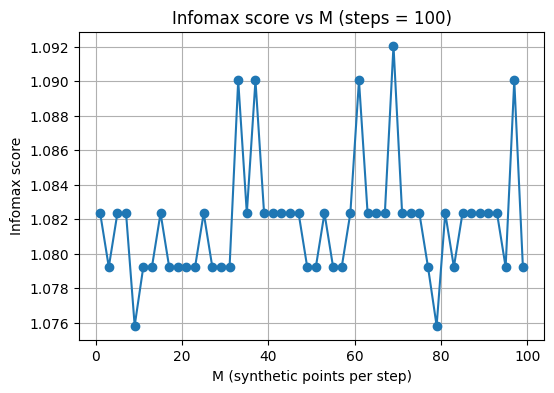

In [48]:
def infomax(labels):
    """Entropy of cluster label distribution."""
    M = len(labels)
    _, counts = np.unique(labels, return_counts=True)
    probs = counts / M
    H = -np.sum(probs * np.log(probs))
    return H

infomax_results = []
for M_try in M_values:
    new_data = data_matrix.copy()
    for t in range(steps):
        kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42)
        cluster_assigns = kmeans.fit_predict(new_data)
        new_data = update_dataset(new_data, cluster_assigns, int(M_try), 3, random_state=42 + t)
    # final clustering and infomax on the original samples
    kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42)
    final_assigns = kmeans.fit_predict(new_data)
    labels_orig = final_assigns[:data_matrix.shape[0]]
    infomax_score = infomax(labels_orig)
    infomax_results.append(infomax_score)

plt.figure(figsize=(6,4))
plt.plot(M_values, infomax_results, marker='o')
plt.xlabel('M (synthetic points per step)')
plt.ylabel('Infomax score')
plt.title(f'Infomax score vs M (steps = {steps})')
plt.grid(True)
plt.show()



<h2>Can CLL be used as an internal method of evaluation of clustering results?</h2>

<h3>Study of centroids fluctuations</h3>

In [49]:
kmeans = KMeans(n_clusters=3, random_state=42)
cluster_assignments = kmeans.fit_predict(data_matrix)
print(cluster_assignments)
original_centroids=mean_clusters(data_matrix,cluster_assignments,3)
print("Initial centroids: ")
print(original_centroids)


new_data = data_matrix.copy()
steps = 100  # Number of iterations

# Iteratively augment the dataset and re-cluster.
for i in range(steps):
    # Re-fit KMeans on the current dataset and obtain assignments
    kmeans = KMeans(n_clusters=3, random_state=42)
    cluster_assignments = kmeans.fit_predict(new_data)
    
    # Recompute cluster statistics on the updated dataset
    means = mean_clusters(new_data, cluster_assignments, 3)
    variances = variance_clusters(new_data, cluster_assignments, 3)
    
    # Update dataset by adding synthetic points sampled from cluster distributions
    # Pass n_clusters as integer (3) to match update_dataset signature.
    new_data = update_dataset(new_data, cluster_assignments, M, 3, random_state=42 + i)
print("Centroids after CLL")
print(means)

means_difference=original_centroids-means
print("Centroids fluctuations:")
print(means_difference)
difference_norms= np.linalg.norm(means_difference, axis=1)
print("Norm of fluctuations of the 3 centroids: ",difference_norms)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 0 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 2 0 0 0 0 2 0 0 0 0
 0 0 2 2 0 0 0 0 2 0 2 0 2 0 0 2 2 0 0 0 0 0 2 0 0 0 0 2 0 0 0 2 0 0 0 2 0
 0 2]
Initial centroids: 
[[6.85384615 3.07692308 5.71538462 2.05384615]
 [5.006      3.418      1.464      0.244     ]
 [5.88360656 2.74098361 4.38852459 1.43442623]]
Centroids after CLL
[[5.85765361 2.74916672 4.3776692  1.43705088]
 [6.85077832 3.00740122 5.73658864 2.01562132]
 [5.04227562 3.38324661 1.4791228  0.26412856]]
Centroids fluctuations:
[[ 0.99619254  0.32775635  1.33771542  0.61679527]
 [-1.84477832  0.41059878 -4.27258864 -1.77162132]
 [ 0.84133093 -0.642263    2.90940179  1.17029766]]
Norm of fluctuations of the 3 centroids:  [1.808243   4.99654422 3.3097666 ]


In [50]:
from scipy.optimize import linear_sum_assignment


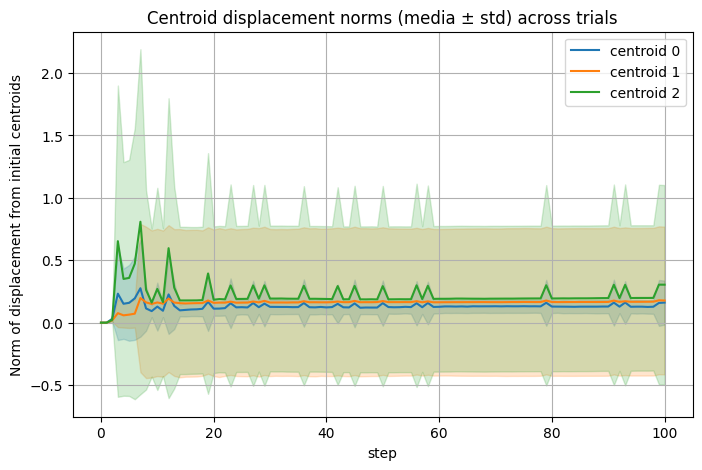

[np.float64(0.15811196576361777), np.float64(0.17926771799609786), np.float64(0.30461308079913263)]


In [51]:

# --- Funzione per riallineare i centroid ad ogni step ---
def align_centroids(ref_means, new_means):
    """
    Allinea i nuovi centroid all'ordine dei centroid precedenti
    usando il minimo matching (Hungarian algorithm)
    """
    K = ref_means.shape[0]
    cost = np.linalg.norm(ref_means[:, None, :] - new_means[None, :, :], axis=2)
    row_ind, col_ind = linear_sum_assignment(cost)
    aligned = np.zeros_like(new_means)
    for r, c in zip(row_ind, col_ind):
        aligned[r] = new_means[c]
    return aligned


# --- Modifica: run_cll con riallineamento ---
def run_cll(data_matrix, M, steps, n_clusters=3, base_random=0):
    new_data = data_matrix.copy()
    history = [] # history dei centroid
    
    # First KMeans execution
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init='auto')
    kmeans.fit(new_data)
    cluster_assignments = kmeans.labels_
    means = mean_clusters(new_data, cluster_assignments, n_clusters)
    history.append(means.copy())
    
    # Execute CLL with centroid alignment
    for t in range(steps):
        kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init='auto')
        cluster_assignments = kmeans.fit_predict(new_data)
        means = mean_clusters(new_data, cluster_assignments, n_clusters)
        
        # Riallineiamo i centroid rispetto ai precedenti
        ref = history[-1]
        means = align_centroids(ref, means)
        
        history.append(means.copy())
        
        new_data = update_dataset(new_data, cluster_assignments, M,
                                 n_clusters, random_state=base_random + t)
    
    return np.array(history)  # shape: (steps+1, K, dim)


# ---- Parametri ----
n_trials = 30
steps = 100
M = 10
n_clusters = 3

# ---- Multi-run ----
all_histories = np.zeros((n_trials, steps+1, n_clusters, data_matrix.shape[1]))
for r in range(n_trials):
    hist = run_cll(data_matrix, M, steps, n_clusters=n_clusters, base_random=1000 + r)
    all_histories[r] = hist

# ---- Analisi spostamento centroidi ----
diffs = all_histories - all_histories[:, 0:1, :, :]
norms = np.linalg.norm(diffs, axis=-1)  # shape: (n_trials, steps+1, K)

mean_norms = norms.mean(axis=0)
std_norms = norms.std(axis=0)

# ---- Plot ----
plt.figure(figsize=(8,5))
steps_range = np.arange(steps+1)
colors = ['C0','C1','C2']

for k in range(n_clusters):
    plt.plot(steps_range, mean_norms[:,k], label=f'centroid {k}', color=colors[k])
    plt.fill_between(steps_range,
                     mean_norms[:,k]-std_norms[:,k],
                     mean_norms[:,k]+std_norms[:,k],
                     color=colors[k], alpha=0.2)

plt.xlabel('step')
plt.ylabel('Norm of displacement from initial centroids')
plt.title('Centroid displacement norms (media ± std) across trials')
plt.legend()
plt.grid(True)
plt.show()
k=n_clusters-1

final_mean_boxplot=[mean_norms[99,0],mean_norms[99,1],mean_norms[99,2]]
final_stddev_boxplot=[std_norms[99,0],std_norms[99,1],std_norms[99,2]]
print(final_mean_boxplot)

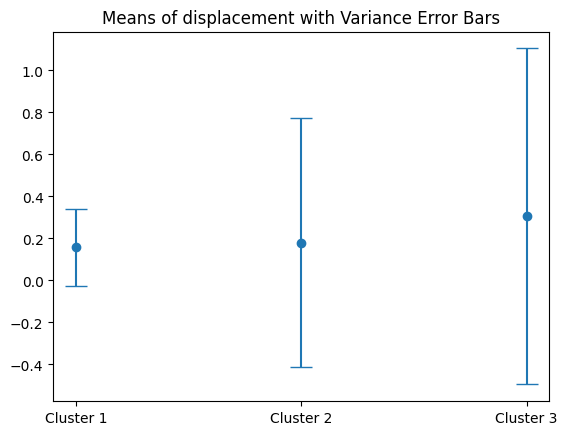

In [52]:
plt.errorbar(x=[1,2,3], y=final_mean_boxplot, yerr=final_stddev_boxplot,
             fmt='o', capsize=8)
plt.xticks([1,2,3], [f"Cluster {i+1}" for i in range(3)])
plt.title("Means of displacement with Variance Error Bars")
plt.show()


<h3>Let's compare the displacement with the distance between clusters </h3>

In [53]:
import numpy as np
print("Distances between cluster centers (1° Kmeans)")

print("Norm difference between cluster 1 and 2 centers:", np.linalg.norm(mean_first_ex[0, :] - mean_first_ex[1, :]))
print("Norm difference between cluster 1 and 3 centers:",  np.linalg.norm(mean_first_ex[0, :] - mean_first_ex[2, :]))
print("Norm difference between cluster 2 and 3 centers:",  np.linalg.norm(mean_first_ex[1, :] - mean_first_ex[2, :]))

print("Dispacement after applying CLL clustering:")

diff = mean_final_ex - mean_first_ex   # shape (3, 4)

print(np.linalg.norm(diff, axis=1) )

Distances between cluster centers (1° Kmeans)
Norm difference between cluster 1 and 2 centers: 4.988054041834385
Norm difference between cluster 1 and 3 centers: 1.7884235436555784
Norm difference between cluster 2 and 3 centers: 3.346416464356445
Dispacement after applying CLL clustering:
[0.08336428 0.05657338 0.02978083]


<h3>Can we evaluate the quality of the cluster obtained by comparing Dispacement after CLL and distance between original cluster centroids</h3>